<a href="https://colab.research.google.com/github/Medrodi/MIIGAIK-Computer-Math/blob/main/5.%20%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0%20Pandas.%20%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9%20%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [ ]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


1) Выведите последние 10 элеметнов датасета

In [ ]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [ ]:
df.shape

(32561, 15)

3) Какие типы данных у элементов этого датасета?

In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


4) Какие признаки имеют пропуски?

In [ ]:
df.isnull().any()

,0
age,False
workclass,True
fnlwgt,False
education,False
education.num,False
marital.status,False
occupation,True
relationship,False
race,False
sex,False


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: workclass: Возможно некоторые люди не хотели рассказывать, где они работают. Возможно они нелегально роаботают и не хоятт давать ответ на данный вопрос.
native.country: некоторые люди могут не знать своего происхождения, они могут быть сиротами или нелегально находиться в стране.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [ ]:
display(df['workclass'].unique())
df['workclass'].nunique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', nan, ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

8

7) Какой средний возраст женщин и мужчин?

In [ ]:
df.groupby('sex')['age'].mean()

,age
sex,
Female,36.858230
Male,39.433547


8) Постройте гистограмму(bar) распределения образования людей (education)

<Axes: xlabel='education'>

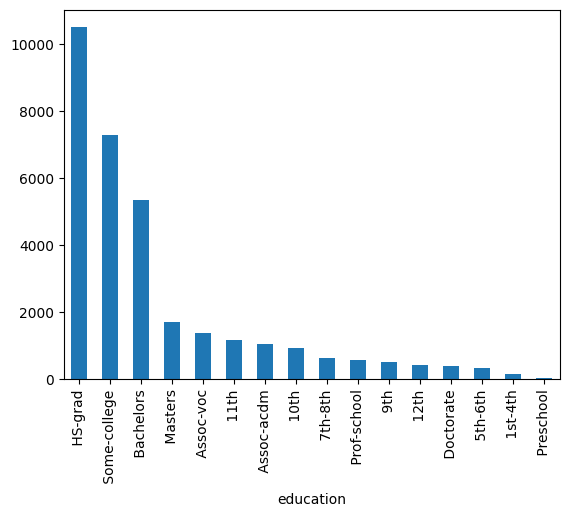

In [ ]:
df['education'].value_counts().plot(kind='bar')

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [ ]:
df.groupby('income')['age'].agg(['mean', 'std'])

,mean,std
income,,
<=50K,36.783738,14.020088
>50K,44.249841,10.519028


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [ ]:
high_edu = (['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate'])
if (df[df['income'] == ">50K"]['education'].isin(high_edu) == False).any():
    print("Неправда")
else:
    print("Правда")

Неправда


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [ ]:
men = df[df['sex'] == 'Male'].copy()
men['married'] = men['marital.status'].str.startswith('Married')
men.groupby('married')['income'].value_counts(normalize=True)


married  income
False    <=50K     0.915505
         >50K      0.084495
True     <=50K     0.559486
         >50K      0.440514
Name: proportion, dtype: float64

Доля зарабатывающих > 50K больше среди женатых

12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



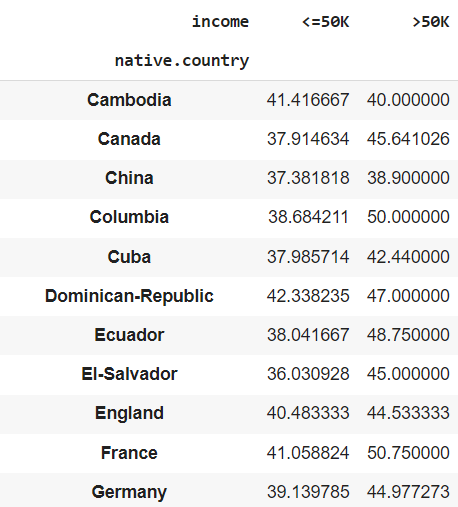

In [ ]:
table = pd.pivot_table(
    df, values="hours.per.week", index=["native.country"], columns=["income"], aggfunc="mean"
)
table

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

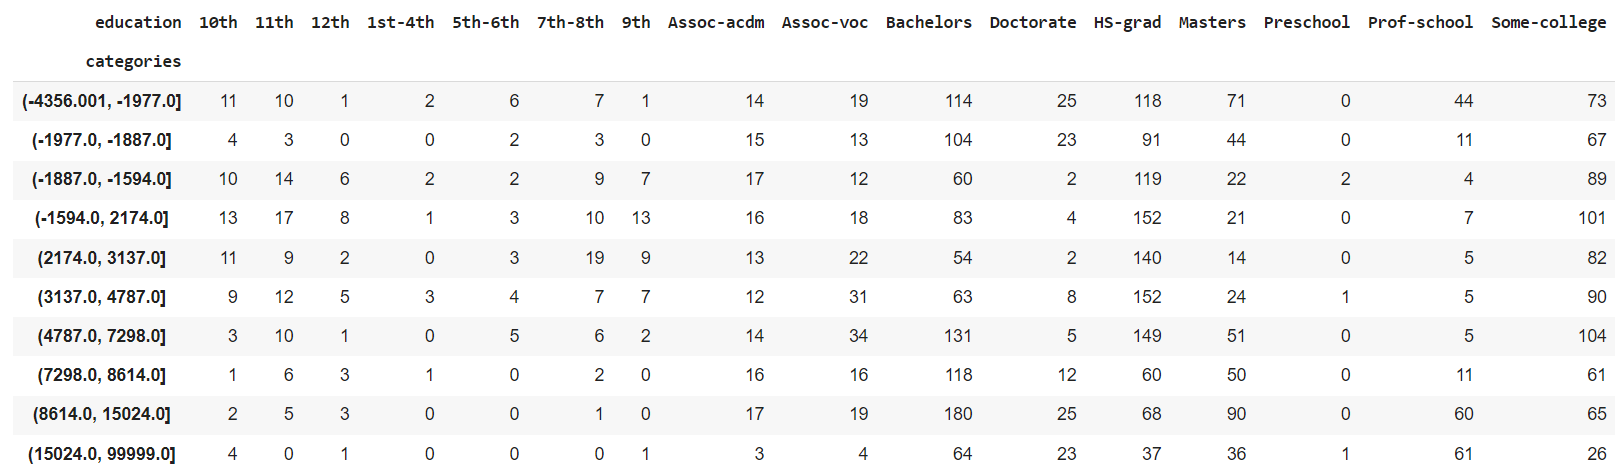

In [ ]:
summary_table = df[['education']].copy()
summary_table["capital.diff"] = df['capital.gain'] - df['capital.loss']

summary_table = summary_table[summary_table['capital.diff'] != 0 ]
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)



summary_pivot = summary_table.pivot_table(
    index="education",
    columns="categories",
    values="education",
    aggfunc="count",
)

summary_pivot

/tmp/ipykernel_39434/2377165479.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  summary_pivot = summary_table.pivot_table(


categories,"(-4356.001, -1977.0]","(-1977.0, -1887.0]","(-1887.0, -1594.0]","(-1594.0, 2174.0]","(2174.0, 3137.0]","(3137.0, 4787.0]","(4787.0, 7298.0]","(7298.0, 8614.0]","(8614.0, 15024.0]","(15024.0, 99999.0]"
education,,,,,,,,,,
10th,11,4,10,13,11,9,3,1,2,4
11th,10,3,14,17,9,12,10,6,5,0
12th,1,0,6,8,2,5,1,3,3,1
1st-4th,2,0,2,1,0,3,0,1,0,0
5th-6th,6,2,2,3,3,4,5,0,0,0
7th-8th,7,3,9,10,19,7,6,2,1,0
9th,1,0,7,13,9,7,2,0,0,1
Assoc-acdm,14,15,17,16,13,12,14,16,17,3
Assoc-voc,19,13,12,18,22,31,34,16,19,4


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [ ]:
women = df[(df['sex'] == 'Female') & (df['native.country'].notna())].copy()
women['high_income'] = women['income'] == '>50K'
women.groupby('native.country')['high_income'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
native.country,,
Yugoslavia,0.333333,3
Taiwan,0.266667,15
France,0.250000,12
Iran,0.250000,8
Japan,0.250000,20
Italy,0.238095,21
China,0.238095,21
Canada,0.230769,39
Greece,0.200000,5


15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [ ]:
ndf = df.copy()
def f(income):
    if income == '>50K':
        return np.random.randint(51, 201)
    else:
        return np.random.randint(0, 51)
ndf['magic_salary'] = ndf['income'].apply(f)
ndf['magic_salary_per_hour'] = ndf['magic_salary'] / df['hours.per.week']
print(ndf.groupby('education')['magic_salary_per_hour'].mean().sort_values(ascending=False)
)


education
Doctorate       2.866995
Prof-school     2.351949
Masters         2.182741
Bachelors       1.676861
Assoc-acdm      1.530707
Assoc-voc       1.375648
Some-college    1.264522
HS-grad         1.121586
10th            1.117258
11th            1.085584
7th-8th         1.029432
12th            0.999205
9th             0.902796
1st-4th         0.864746
5th-6th         0.796664
Preschool       0.773534
Name: magic_salary_per_hour, dtype: float64


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [ ]:
df = pd.read_csv('./train.csv')
df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

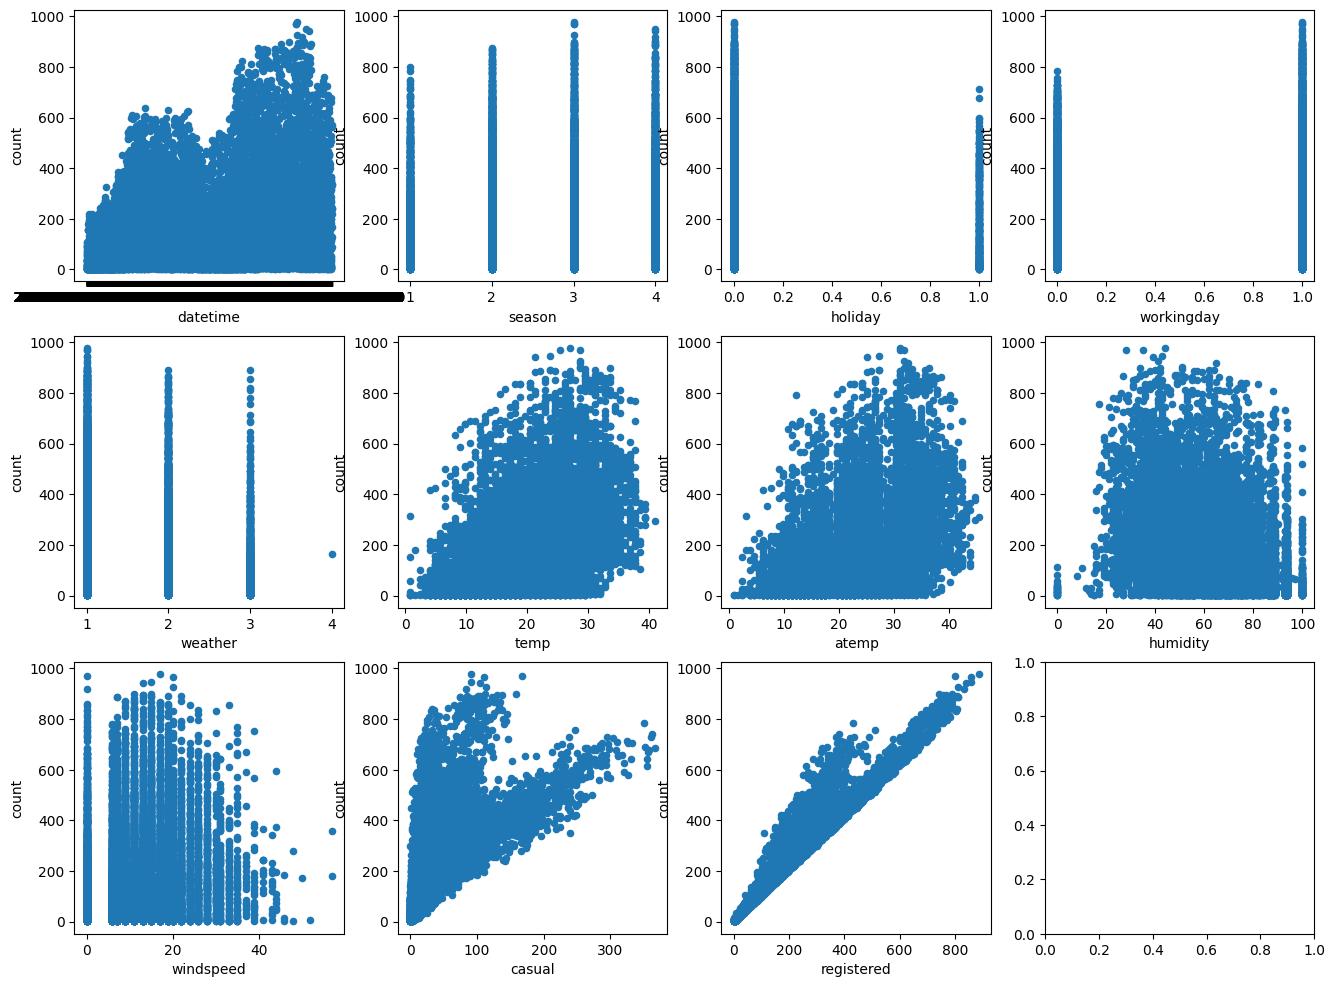

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "count", kind="scatter", ax=axes[idx // 4, idx % 4])



### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





ответ:По графику ниже видно, что есть прямая зависимость от времён года. Зимой велосипеды берут меньше всего. Пик приходится на июнь-октябрь.

<Axes: xlabel='month', ylabel='count'>

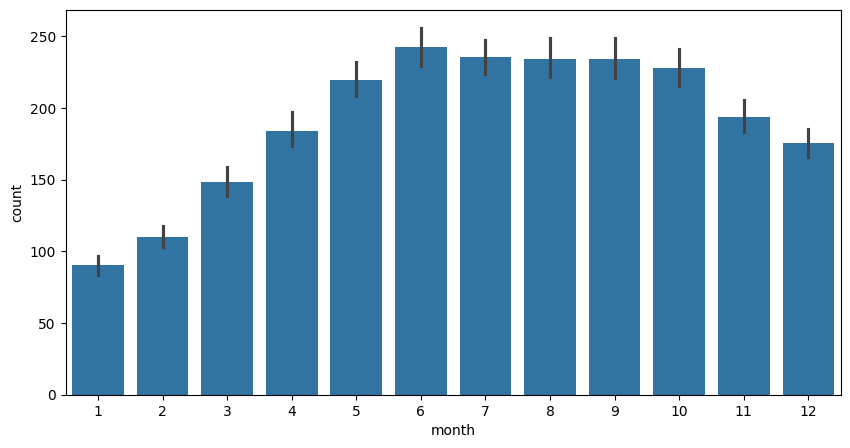

In [ ]:
df['datetime']=pd.to_datetime(df['datetime'])
df['month']=df['datetime'].dt.month

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='month', y='count')


#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: Чем больше зарегистрированных пользователей тем больше прокатов. Чем лучше погода, тем больше прокатов

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



Text(0.5, 1.0, 'Матрица корреляций признаков')

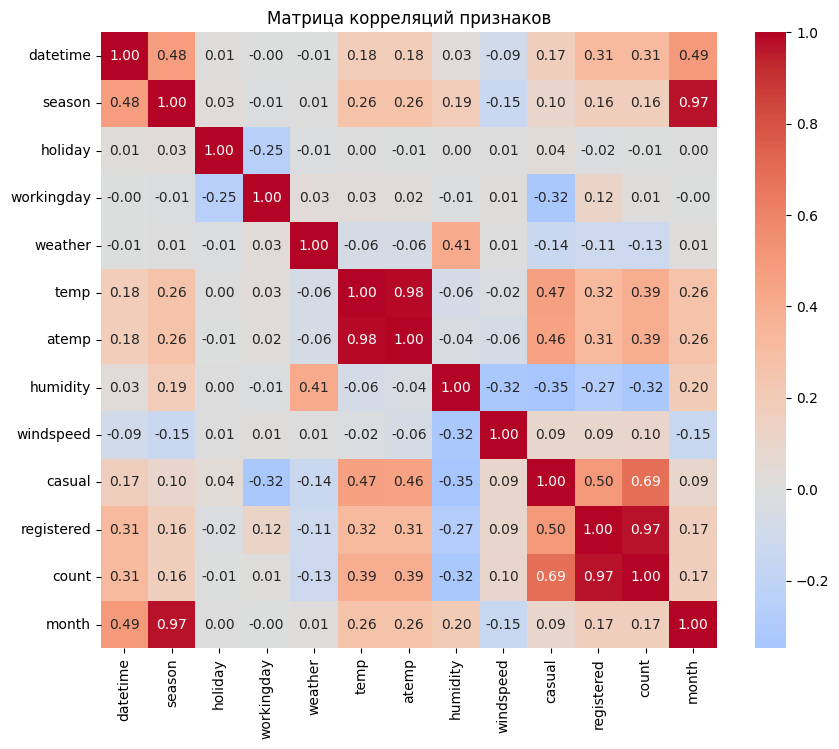

In [ ]:
import seaborn as sns

corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляций признаков')

**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

ОтветМеньше всего коррелирует с holiday, workingday, windspeed
Больше всего коррелирует с datetime, temp, atemp, casual, registered

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



<Axes: xlabel='month', ylabel='count'>

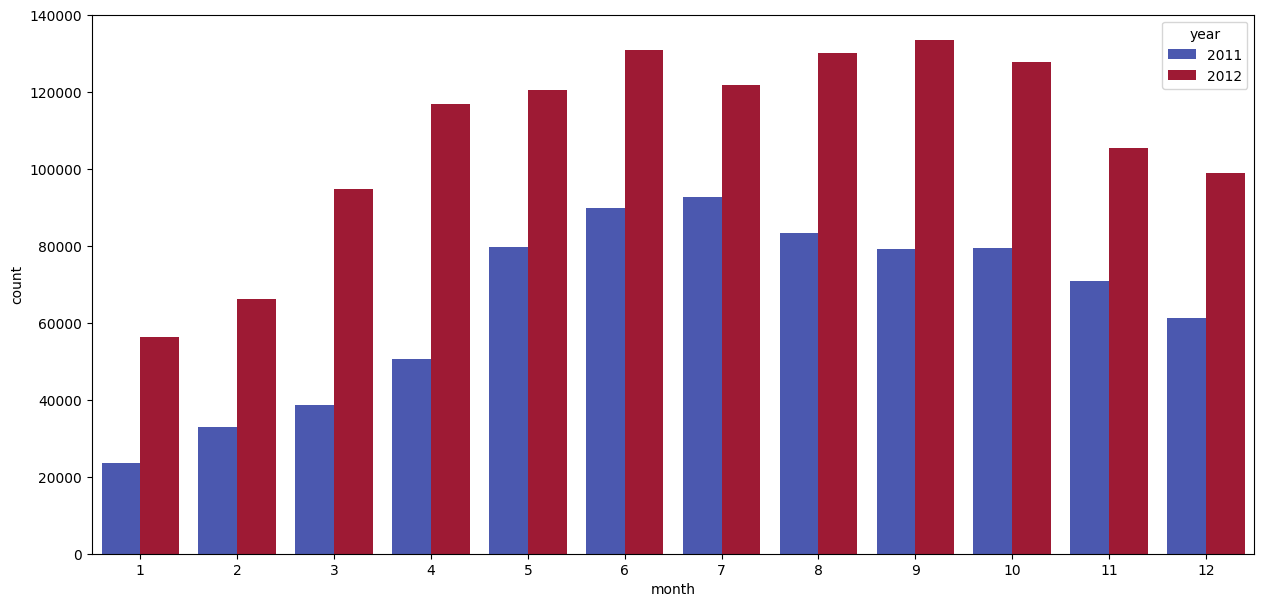

In [ ]:
df['year'] = df['datetime'].dt.year

date_data = df.groupby(['year', 'month'])['count'].sum().reset_index()
plt.figure(figsize=(15, 7))
sns.barplot(data=date_data, x='month', y='count', hue='year', palette='coolwarm')


**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ: Компания растёт, а следовательно и число прокатов тоже. Можно заметить что количество пользователей напрямую коррелирует с количеством проката.

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



/tmp/ipykernel_39434/3021681534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weekday', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_39434/3021681534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weather', ax=axes[1], palette='coolwarm')


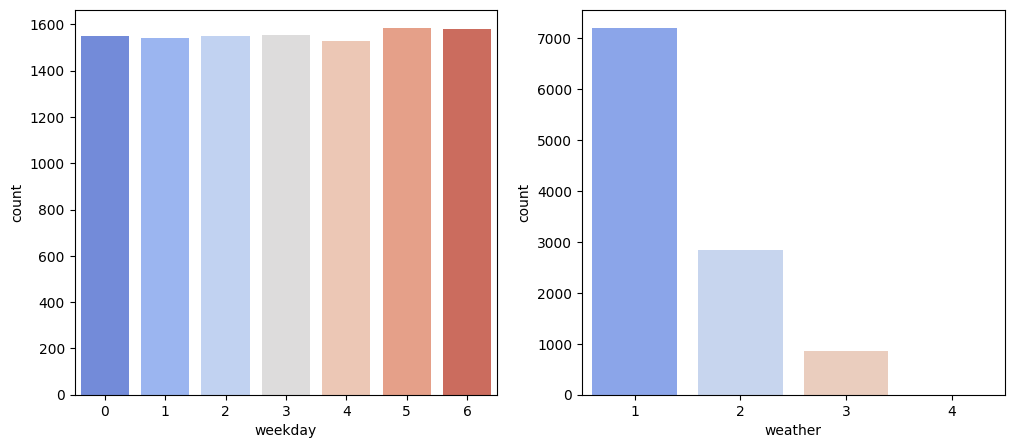

In [ ]:
df['weekday'] = df['datetime'].dt.weekday
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='weekday', ax=axes[0], palette='coolwarm')
sns.countplot(data=df, x='weather', ax=axes[1], palette='coolwarm')
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ: Данные измерялись каждый день. Видимо вне зависимости от различных факторов. Как раз реальность распределения по погоде хорошо прослеживается.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?


    
Ответ: Равномерным распределением

### 5. Распределение

Постройте распределение целевого признака.


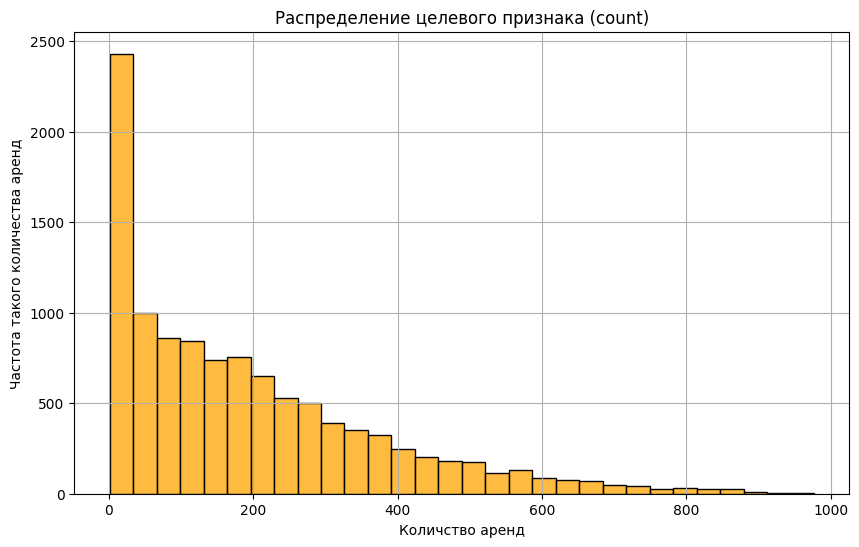

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['count'], color="orange", bins=30)
ax.set(xlabel="Количство аренд", ylabel="Частота такого количества аренд", title='Распределение целевого признака (count)')
ax.grid()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ:В среднем около 200 прокатов

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



<Axes: xlabel='temp', ylabel='atemp'>

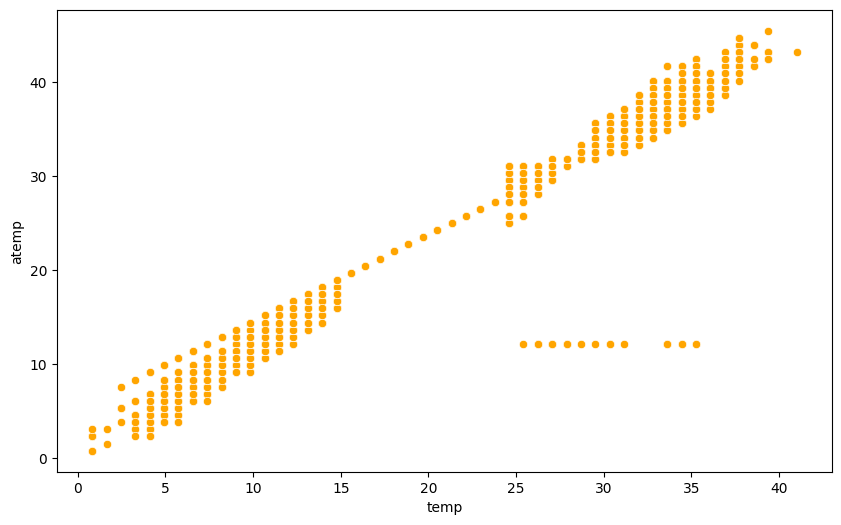

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(df, x='temp', y='atemp', color="orange")

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ: На графике заметны аномалии в зоне temp [25;35] и atemp +- 12. Возможно в эти дни был стльный холодный ветер. Или в эти дни ошибались в вводом температуры и вместо 22 писали 12 и т.д.

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




[Text(0.5, 0, 'Месяц'), Text(0, 0.5, 'Количество прокатов')]

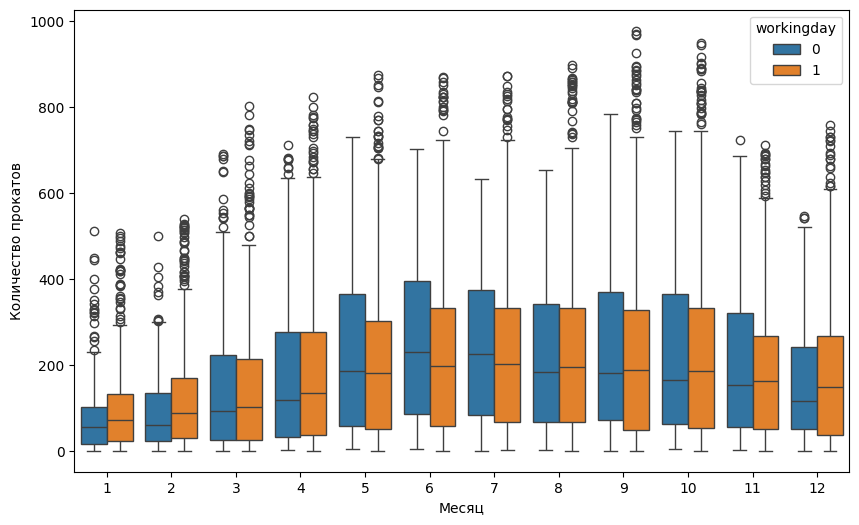

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(df, x='month', y='count', hue="workingday")
ax.set(xlabel="Месяц", ylabel="Количество прокатов")

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ: Можно заметить, что в "благоприятные" месяцы: май-ноябрь больше всго берётся велосипедов. Скорее всго люди в это время катаются для развлечения в своё свободное время. А зимой больше аренда в рабочие дни: возможно люди работают в сфере велосипедов или используются для работы, например, курьеры.

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
colab = False # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [12]:
if colab:
    df = pd.read_csv('/content/drive/My Drive/Data/StudentsPerformance.csv')
else:
    df = pd.read_csv('StudentsPerformance.csv')

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


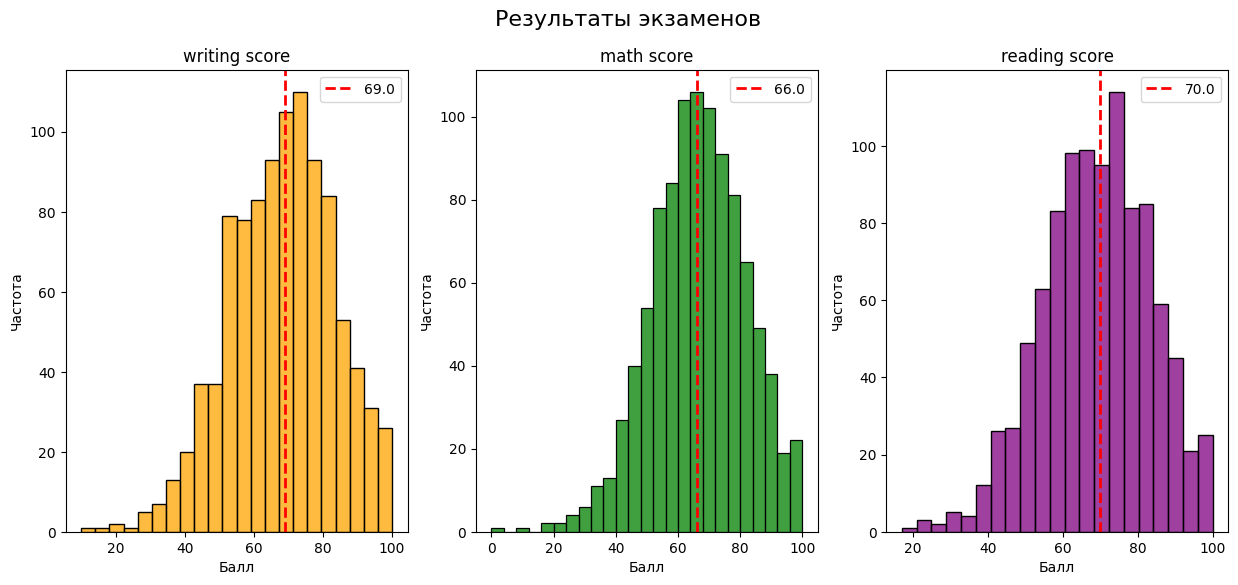

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

subj = ['writing score','math score', 'reading score']

sns.histplot(df['writing score'], ax=ax[0], color="orange")
sns.histplot(df['math score'], ax=ax[1], color="green")
sns.histplot(df['reading score'], ax=ax[2], color="purple")
fig.suptitle("Результаты экзаменов", fontsize=16)

for i in range(3):
  med = df[subj[i]].median()
  ax[i].axvline(med, color='red', linestyle='--', linewidth=2, label=f"{med}")
  ax[i].set_title(subj[i])
  ax[i].set_xlabel('Балл')
  ax[i].set_ylabel('Частота')
  ax[i].legend()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


In [26]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


[Text(0.5, 0, 'Уровень образования родителей')]

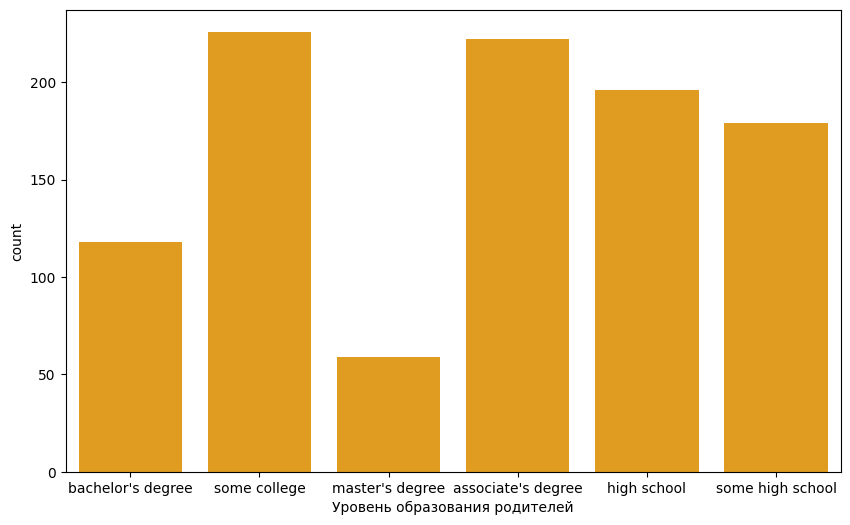

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(df, x='parental level of education', color='orange')
ax.set(xlabel="Уровень образования родителей")

/tmp/ipykernel_2205/587826330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="parental level of education", y="math score", palette='inferno')


[Text(0.5, 0, 'Уровень образования родителей'),
 Text(0.5, 1.0, 'Балл по математике в зависимости от уровня образования родителей')]

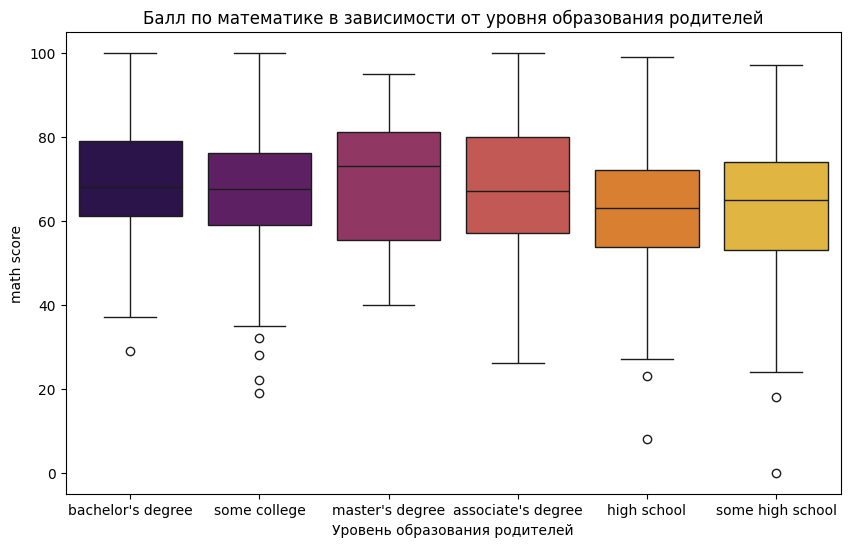

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(df, x="parental level of education", y="math score", palette='inferno')
ax.set(xlabel='Уровень образования родителей', title='Балл по математике в зависимости от уровня образования родителей')

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [36]:
len(df[(df['gender'] == "female") & (df['math score'] > 90) & (df['writing score'] > 90)
    & (df['reading score'] > 90)])

17

#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [38]:
df.groupby('gender')[['writing score','math score', 'reading score']].agg(['min', 'max','median'])


writing score             math score             reading score       \
                 min  max median        min  max median           min  max   
gender                                                                       
female            10  100   74.0          0  100   65.0            17  100   
male              15  100   64.0         27  100   69.0            23  100   

               
       median  
gender         
female   73.0  
male     66.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [43]:
df['avg_score'] = (df['math score'] + df['writing score'] + df['reading score'])/3
df.groupby(['gender', 'lunch', 'test preparation course'])[['avg_score']].mean()

#да обед и подготовка влияют на среднйи балл. Студенты со Standart lunch
# и Подготовкой к тесту получают в среднем выше балл


avg_score
gender lunch        test preparation course           
female free/reduced completed                69.528571
                    none                     59.501401
       standard     completed                77.479532
                    none                     70.961240
male   free/reduced completed                65.721311
                    none                     58.323810
       standard     completed                73.513274
                    none                     65.486043

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

<Axes: xlabel='parental level of education', ylabel='count'>

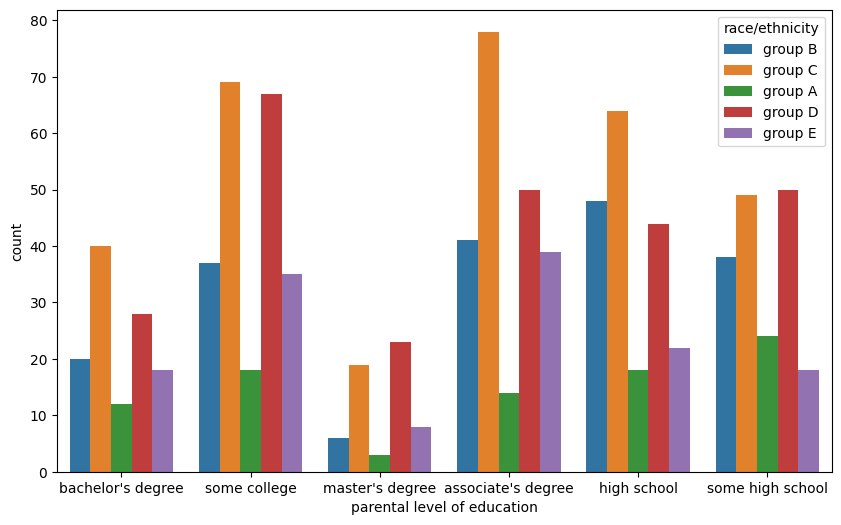

In [50]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(df, hue ='race/ethnicity', x='parental level of education')

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

<Axes: xlabel='test preparation course', ylabel='count'>

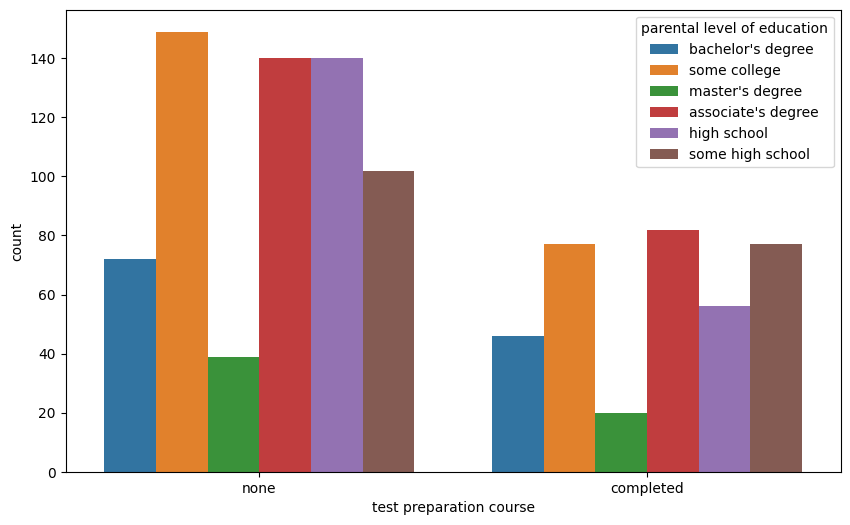

In [51]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(df, hue ='parental level of education', x='test preparation course')

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

[Text(0.5, 1.0, 'Процент сдавших математику')]

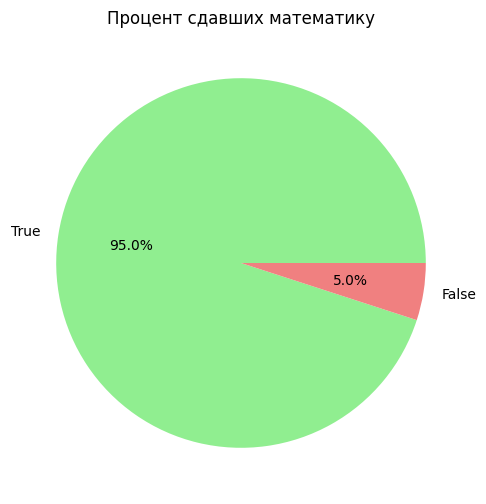

In [59]:
df['math_complete'] = df['math score'] > 40
mc_counts = df['math_complete'].value_counts()

fig, ax = plt.subplots(figsize=(10,6))

ax.pie(mc_counts, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], labels=mc_counts.index)
ax.set(title="Процент сдавших математику")

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

/tmp/ipykernel_2205/2273257169.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='grades', order=order, palette='Set2')


<Axes: xlabel='grades', ylabel='count'>

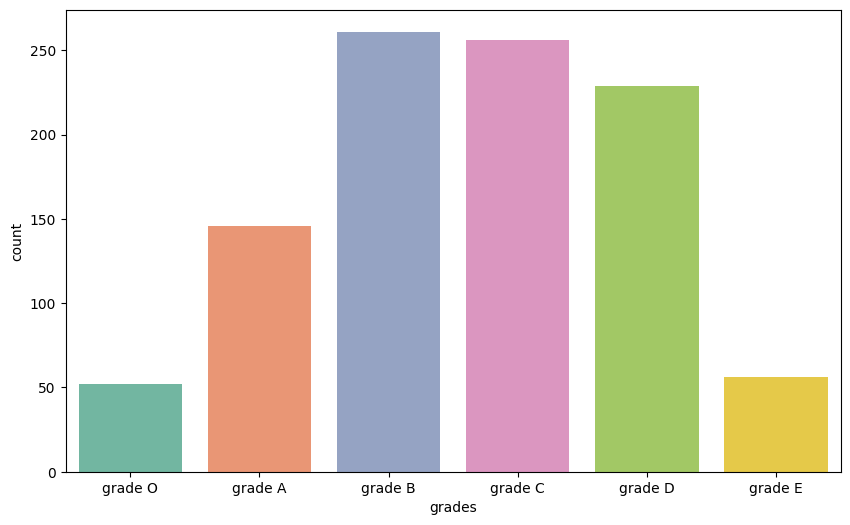

In [66]:
df['grades'] = 'grade E'
df.loc[(df['avg_score'] > 40) & (df['math score'] > 40), 'grades'] = "grade D"
df.loc[(df['avg_score'] >= 60) & (df['math score'] > 40), 'grades'] = "grade C"
df.loc[(df['avg_score'] >= 70) & (df['math score'] > 40), 'grades'] = "grade B"
df.loc[(df['avg_score'] >= 80) & (df['math score'] > 40), 'grades'] = "grade A"
df.loc[(df['avg_score'] >= 90) & (df['math score'] > 40), 'grades'] = "grade O"


fig, ax = plt.subplots(figsize=(10,6))
order = ['grade O', 'grade A', 'grade B', 'grade C', 'grade D', 'grade E']
sns.countplot(df, x='grades', order=order, palette='Set2')

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

<Axes: xlabel='grades', ylabel='count'>

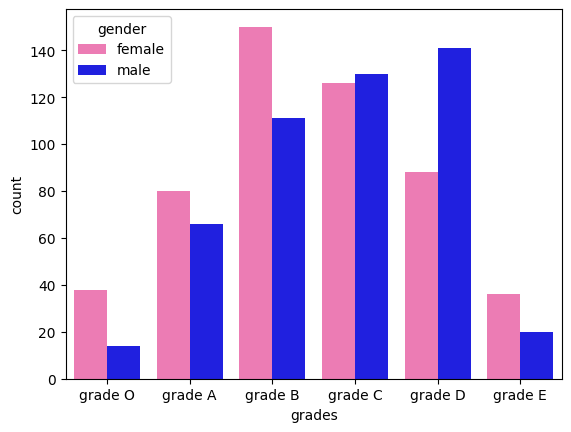

In [73]:
sns.countplot(df, x='grades', hue='gender', order=order, palette=['hotpink', 'blue'])